## Explaratory Data Analysis (EDA) for the dataset

In [32]:
# importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Importing the necessary functions from the src directory
sys.path.append(os.path.join(os.path.dirname(r"C:\Users\shane\Desktop\churn-prediction\src"), 'src'))
from preprocessing import clean_df


In [33]:
# Importing and cleaning the dataset
import kagglehub

path = kagglehub.dataset_download("muhammadshahidazeem/customer-churn-dataset")

train = pd.read_csv(f"{path}/customer_churn_dataset-training-master.csv")
test  = pd.read_csv(f"{path}/customer_churn_dataset-testing-master.csv")

# Combining train and test datasets for preprocessing
df = pd.concat([train, test], ignore_index=True)

df = clean_df(df)

df = df.drop(columns=['CustomerID'])

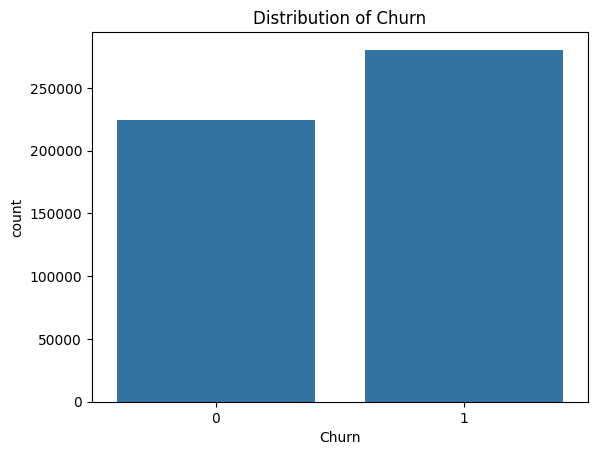

In [34]:

# Univariate analysis plot
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
plt.show()

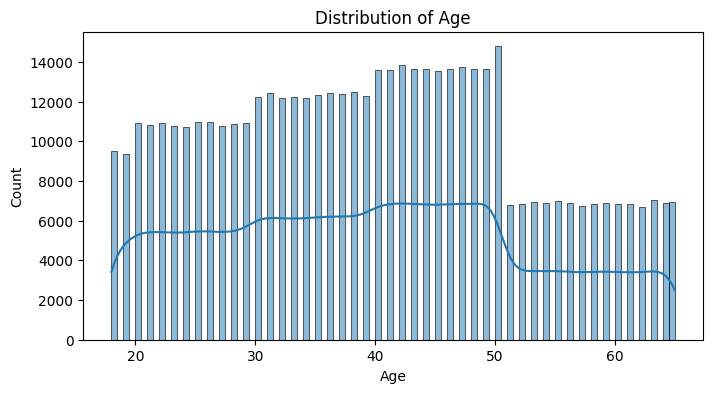

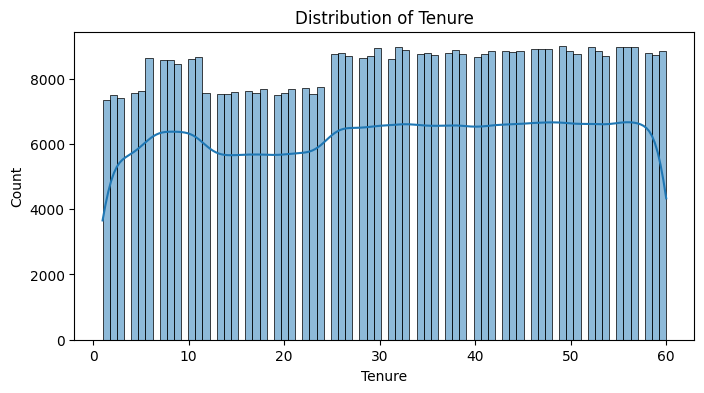

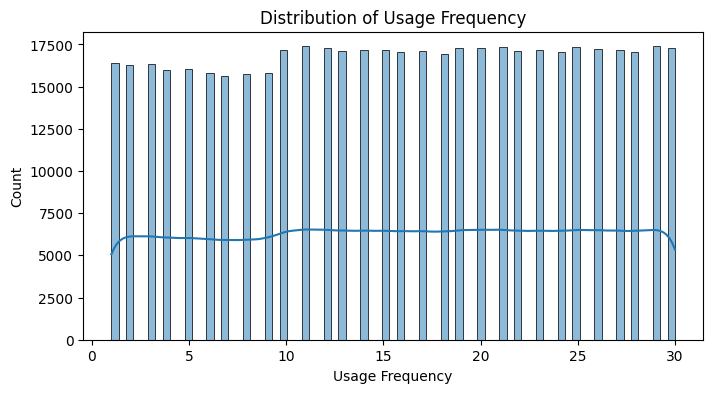

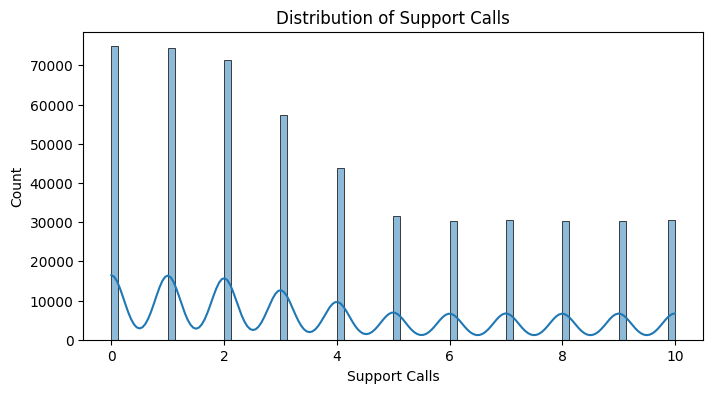

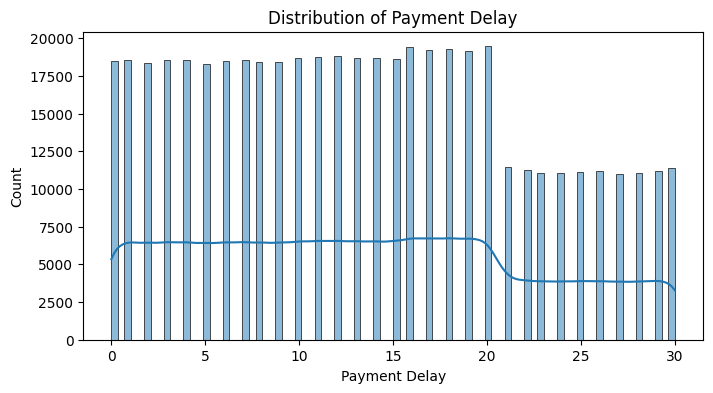

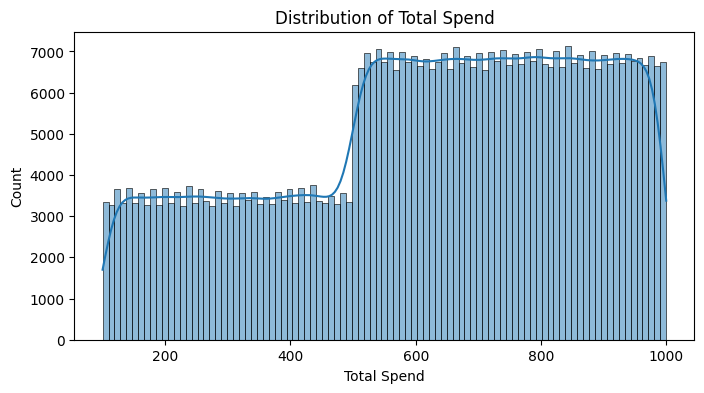

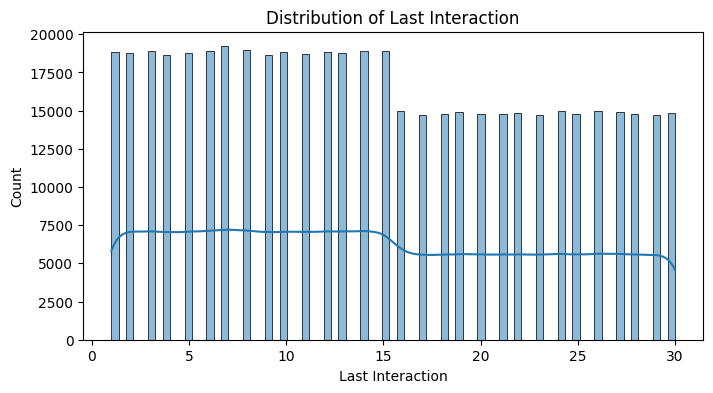

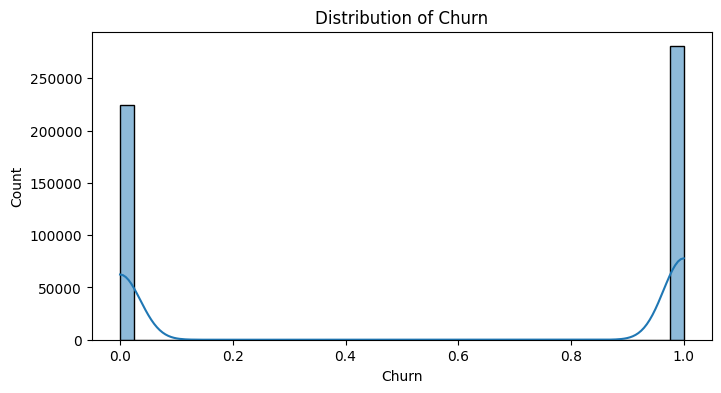

In [35]:
# Numerical features distribution
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.show()

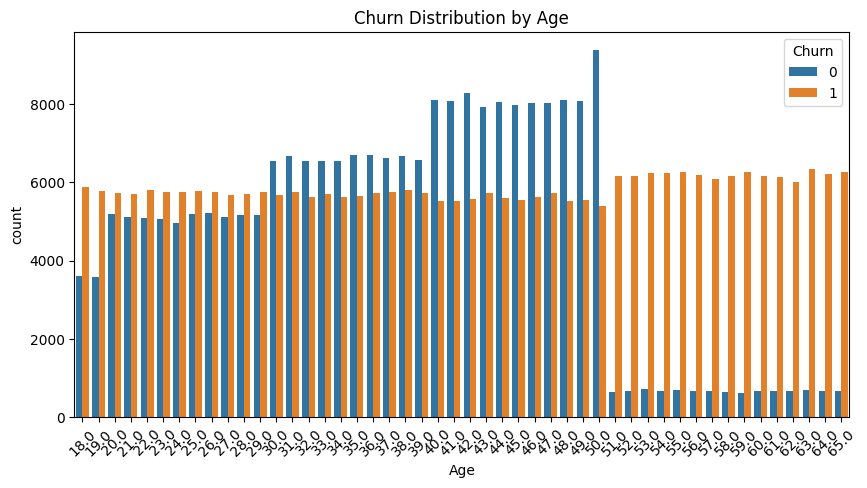

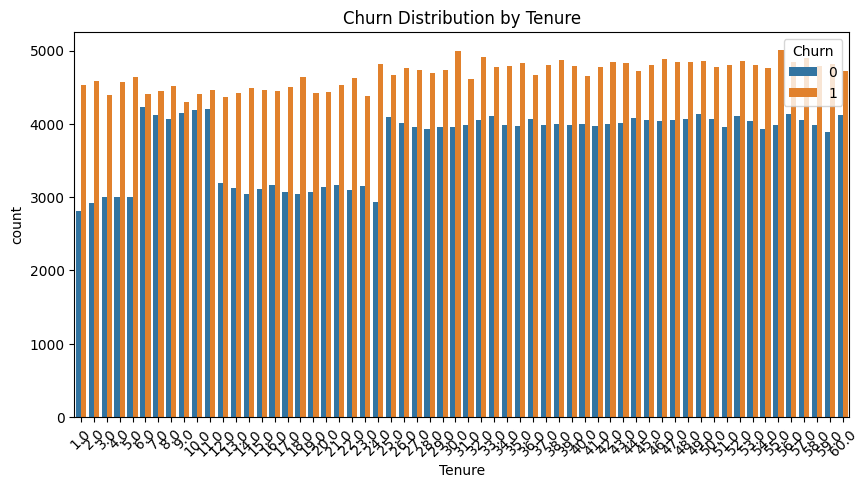

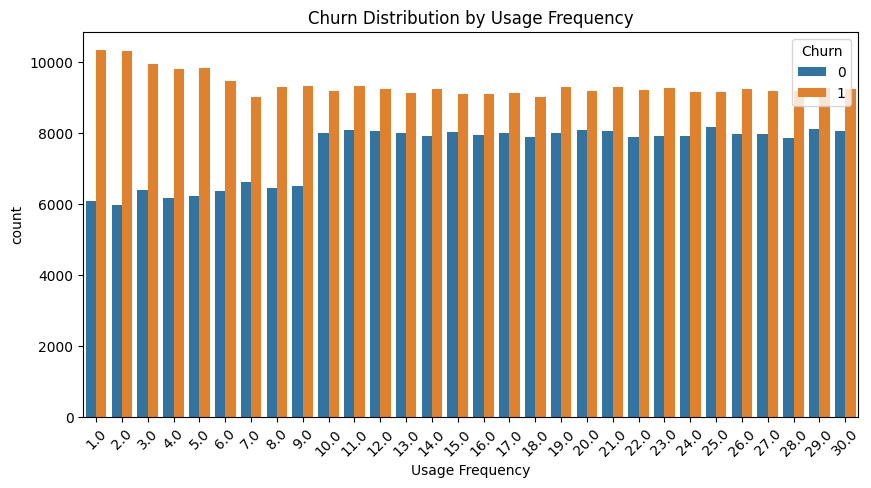

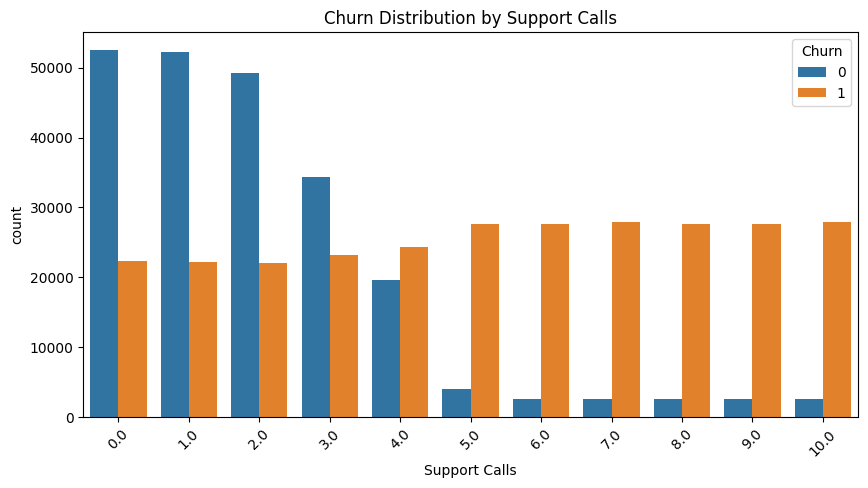

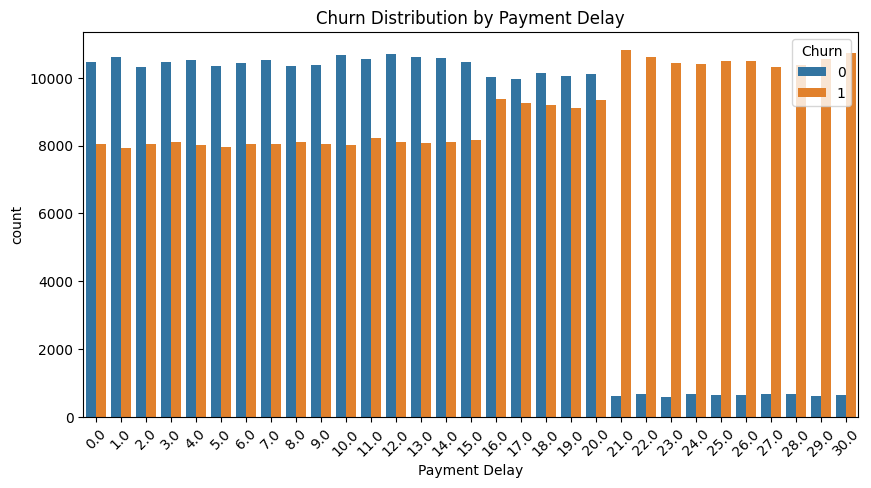

c:\Users\shane\Desktop\churn-prediction\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


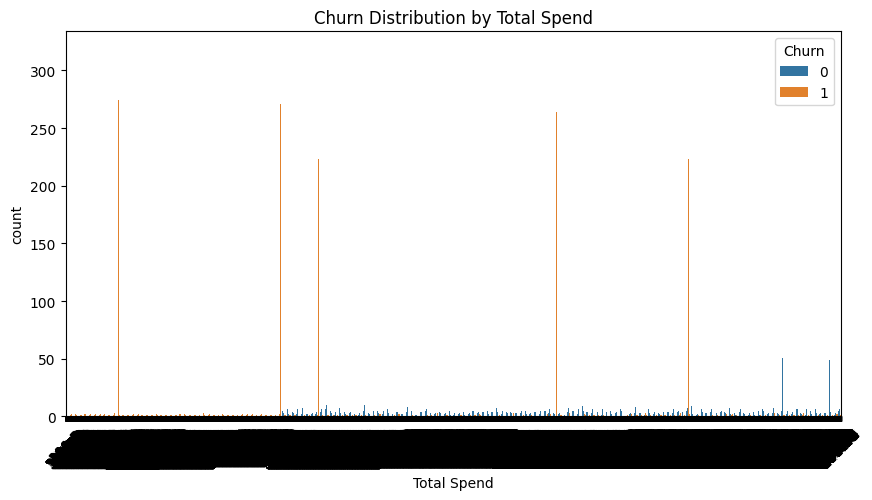

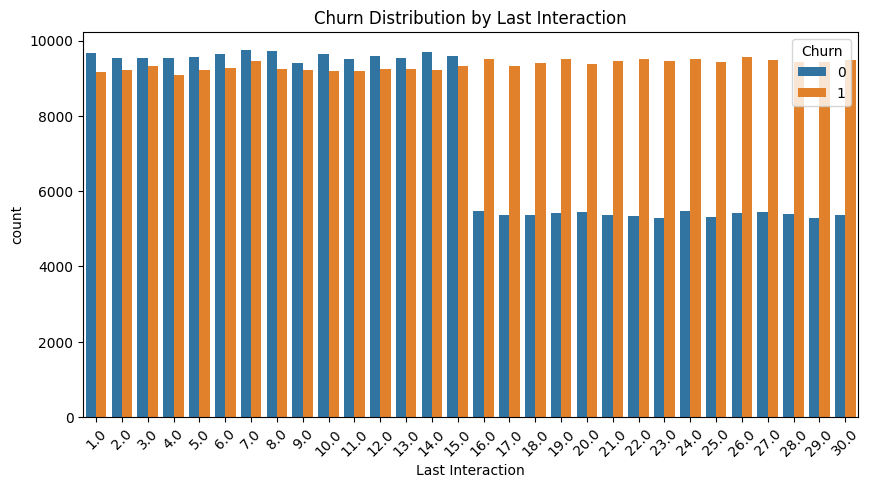

In [38]:
# Sum of Churn distribution by numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove('Churn')  # Exclude target variable
for feature in numerical_features:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=feature, hue='Churn', data=df)
    plt.title(f'Churn Distribution by {feature}')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    plt.show()